In [5]:
# ── Setup: locate the _prism_ package, imports, registries, style ───────────
import sys, os, time, math, json, random, warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import networkx as nx
warnings.filterwarnings('ignore')

CANDIDATES = [Path('./_prism_'), Path('.'), Path('..') / '_prism_']
PRISM_DIR = next((p.resolve() for p in CANDIDATES if (p / 'mosaic_lct.py').exists()), None)
#assert PRISM_DIR is not None, 'Could not locate the _prism_ package - set PRISM_DIR manually.'
sys.path.insert(0, str(PRISM_DIR))

from run_random_circuits import rrc
from mosaic_lct import mosaic_lct
from compiler import compile_quantum_circuit
from qcirc_generator import generate_ansatz_layout
import quantum_circuits as qfam

import qiskit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# run_random_circuits forces the Agg backend at import — (re)select inline AFTER it
%matplotlib inline

OUT = Path('prism_notebook_results'); OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160, 'savefig.bbox': 'tight',
    'font.size': 9.5, 'axes.titlesize': 10, 'axes.titleweight': 'bold',
    'axes.labelsize': 9.5, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.axisbelow': True, 'legend.fontsize': 8.5,
})

# ── circuit-family registry (seeds match run_benchmark_circuit_partition.py) ─
RQC_DEPTH = 12
FAMILIES = {
    'VQE-HEA': dict(gen=qfam.gen_vqe_hea, seed=400),
    'VQE-UCC': dict(gen=qfam.gen_vqe_ucc, seed=500),
    'QNN':  dict(gen=qfam.gen_qnn,  seed=600),
    'QAOA': dict(gen=qfam.gen_qaoa, seed=700),
    'RQC':  dict(gen=lambda n, rng: generate_ansatz_layout(
                     n, RQC_DEPTH, max_qubits_per_layer=n, rng=rng), seed=900),
}
def make_layout(family, n, seed):
    """Reproduces benchmark_one(): rng = Random(seed + n*17 + family_seed)."""
    rng = random.Random(seed + n * 17 + FAMILIES[family]['seed'])
    return FAMILIES[family]['gen'](n, rng)

# ── method registry: benchmark colour scheme, mosaic-LCT relabelled PRISM ───
PRISM = 'PRISM'
METHOD_ORDER = ['Naive', 'Spectral', 'Louvain', 'Girvan-Newman', 'METIS', 'qdislib',
                'mosaic-KL', 'mosaic-OE', 'mosaic-MI', 'mosaic-BF', PRISM]
METHOD_COLOURS = {
    'Naive': '#95A5A6', 'Spectral': '#7F8C8D', 'Louvain': '#5D6D7E',
    'Girvan-Newman': '#85929E', 'METIS': '#34495E', 'qdislib': '#566573',
    'mosaic-KL': '#A9DFBF', 'mosaic-OE': '#7DCEA0', 'mosaic-MI': '#52BE80',
    'mosaic-BF': '#2ECC71', PRISM: '#1E8449',
}
FAMILY_COLOURS = {'QNN': '#8E44AD', 'QAOA': '#E67E22', 'MPS': '#2980B9', 'RQC': '#C0392B'}
FAMILY_MARKERS = {'QNN': 'o', 'QAOA': 's', 'MPS': '^', 'RQC': 'D'}
FAM_LIST = list(FAMILIES)

def run_all_partition_methods(G, layout, n_qubits, qc_full, seed):
    """{method: (A_set, B_set, runtime_s)}, failures dict — mirrors
    get_all_partition_methods() in run_benchmark_circuit_partition.py."""
    methods, fails = {}, {}
    def _call(name, fn):
        t0 = time.time()
        try:
            res = fn(); dt = time.time() - t0
            if isinstance(res, tuple) and len(res) == 2:
                A, B = set(res[0]), set(res[1])
            elif isinstance(res, dict) and res.get('available') and 'A_set' in res:
                A, B = set(res['A_set']), set(res['B_set'])
            else:
                fails[name] = 'unrecognised return'; return
            if A and B:
                methods[name] = (A, B, dt)
        except Exception as e:
            fails[name] = f'{type(e).__name__}: {e}'
    _call('Naive',         lambda: rrc._naive_bisection(n_qubits))
    _call('Spectral',      lambda: rrc._spectral_bisection(G, n_qubits))
    _call('Louvain',       lambda: rrc._louvain_bisection(G, n_qubits))
    _call('Girvan-Newman', lambda: rrc._girvan_newman_bisection(G, n_qubits))
    _call('METIS',         lambda: rrc._metis_bisection(G, n_qubits))
    _call('qdislib',       lambda: rrc._try_qdislib(layout, n_qubits))
    _call('mosaic-KL',     lambda: rrc.partition_graph(G, n_qubits))
    _call('mosaic-OE',     lambda: rrc._mosaic_syment_static(G, layout, n_qubits))
    _call('mosaic-MI',     lambda: rrc.mosaic_plus_plus(G, layout, n_qubits, qc_full=qc_full))
    _call('mosaic-BF',     lambda: rrc._mosaic_adaptive(G, layout, n_qubits, qc_full, OUT))
    _call(PRISM,           lambda: mosaic_lct(G, layout, n_qubits, qc_full=qc_full, seed=seed))
    return methods, fails

def reconstruct_product(A, B, layout, n):
    """Uncorrected product reconstruction p̂ = p_A ⊗ p_B on the full register
    (cross-partition gates dropped) — the codebase's partition-quality probe."""
    pA, sA = rrc._simulate_subcircuit(A, B, layout, n, 'A')
    pB, sB = rrc._simulate_subcircuit(A, B, layout, n, 'B')
    if pA is None or pB is None:
        return None
    p = pA[rrc._build_recon_index(sA, n)] * pB[rrc._build_recon_index(sB, n)]
    s = p.sum()
    return p / s if s > 0 else None

def savefig(fig, name):
    fig.savefig(OUT / name)
    print(f'[saved] {OUT / name}')

try:
    import pymetis; HAS_METIS = True
except ImportError:
    HAS_METIS = False
print(f'package: {PRISM_DIR}')
print(f'qiskit {qiskit.__version__} | networkx {nx.__version__} | pymetis {HAS_METIS}')
print(f'families: {FAM_LIST} | methods: {len(METHOD_ORDER)}')

ModuleNotFoundError: No module named 'run_random_circuits'

## 1. The four circuit families

One representative instance per family at *n* = 10 (seed 19). QNN is a hardware-efficient ansatz with all-to-all-style ring entanglement (CZ ring per block), QAOA a hierarchical disentangler/isometry tree (CRZ/CRY at doubling scales), MPS a brick-wall staircase (alternating even/odd CNOT layers), and RQC the heterogeneous random ansatz from `qcirc_generator` (1- to 4-qubit gates, depth 8). Their interaction-graph topologies — ring, tree, chain, dense-irregular — are precisely what should differentiate the partition methods.

In [ ]:
# ── per-family structural statistics at n = 10 ───────────────────────────────
N_SHOW, SEED_SHOW = 12, 19
SHOW = {}
stats = []
for fam in FAM_LIST:
    layout = make_layout(fam, N_SHOW, SEED_SHOW)
    qc, _ = compile_quantum_circuit(layout, num_qubits=N_SHOW, use_numeric_params=True)
    G = rrc.build_interaction_graph(layout, N_SHOW)
    SHOW[fam] = (layout, qc, G)
    arities = [len(g['qubits']) for layer in layout for g in layer]
    stats.append(dict(family=fam, layers=len(layout), gates=qc.size(), depth=qc.depth(),
                      one_q=sum(a == 1 for a in arities), two_q=sum(a == 2 for a in arities),
                      multi_q=sum(a > 2 for a in arities),
                      gate_set=len({g['gate'] for layer in layout for g in layer}),
                      graph_edges=G.number_of_edges(),
                      graph_density=round(nx.density(G), 3)))
pd.DataFrame(stats).set_index('family')

,layers,gates,depth,one_q,two_q,multi_q,gate_set,graph_edges,graph_density
family,,,,,,,,,
QNN,46,156,46,120,36,0,4,12,0.182
QAOA,69,102,42,58,44,0,4,11,0.167
MPS,13,117,13,84,33,0,3,11,0.167
RQC,12,96,23,42,32,10,30,48,0.727


[saved] prism_notebook_results/f01_gate_occupancy.png


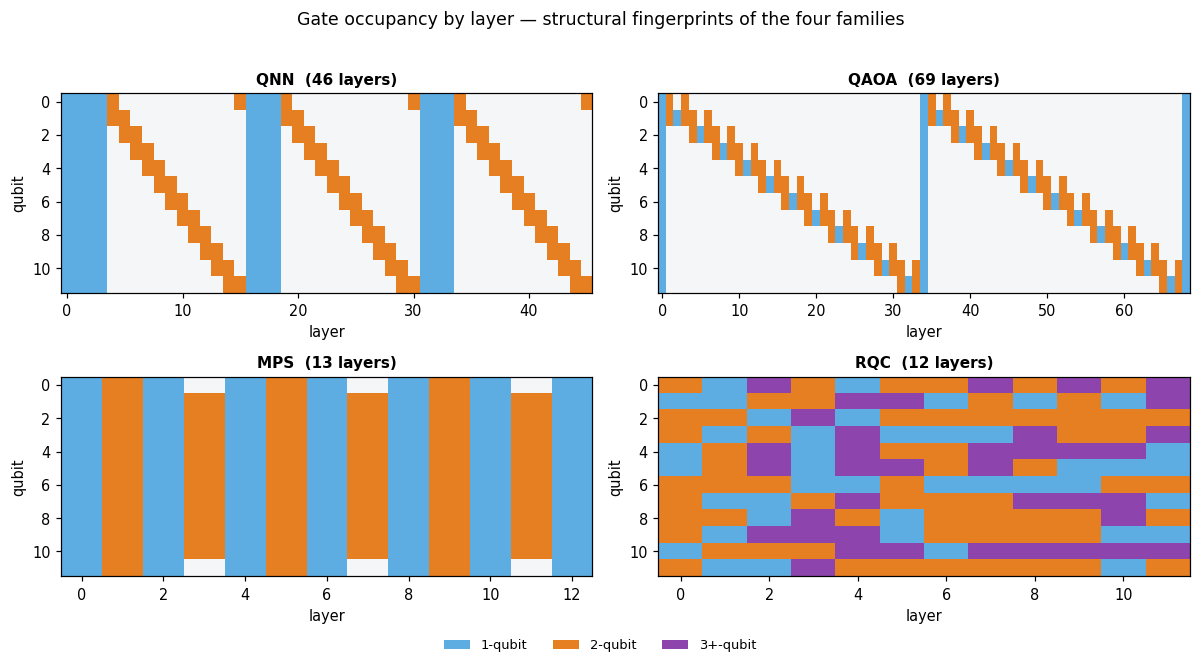

In [ ]:
# ── Figure 1: gate-occupancy heatmaps (layer × qubit, coloured by gate arity) ─
cmap = ListedColormap(['#F4F6F7', '#5DADE2', '#E67E22', '#8E44AD'])
fig, axes = plt.subplots(2, 2, figsize=(11, 5.6))
for ax, fam in zip(axes.flat, FAM_LIST):
    layout = SHOW[fam][0]
    M = np.zeros((N_SHOW, len(layout)))
    for li, layer in enumerate(layout):
        for g in layer:
            v = min(len(g['qubits']), 3)
            for q in g['qubits']:
                M[q, li] = v
    ax.imshow(M, aspect='auto', cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
    ax.set_title(f'{fam}  ({len(layout)} layers)')
    ax.set_xlabel('layer'); ax.set_ylabel('qubit'); ax.grid(False)
handles = [mpl.patches.Patch(fc=c, label=l) for c, l in
           zip(cmap.colors[1:], ['1-qubit', '2-qubit', '3+-qubit'])]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Gate occupancy by layer — structural fingerprints of the four families', y=1.02)
fig.tight_layout(); savefig(fig, 'f01_gate_occupancy.png'); plt.show()

[saved] prism_notebook_results/f02_interaction_graphs.png


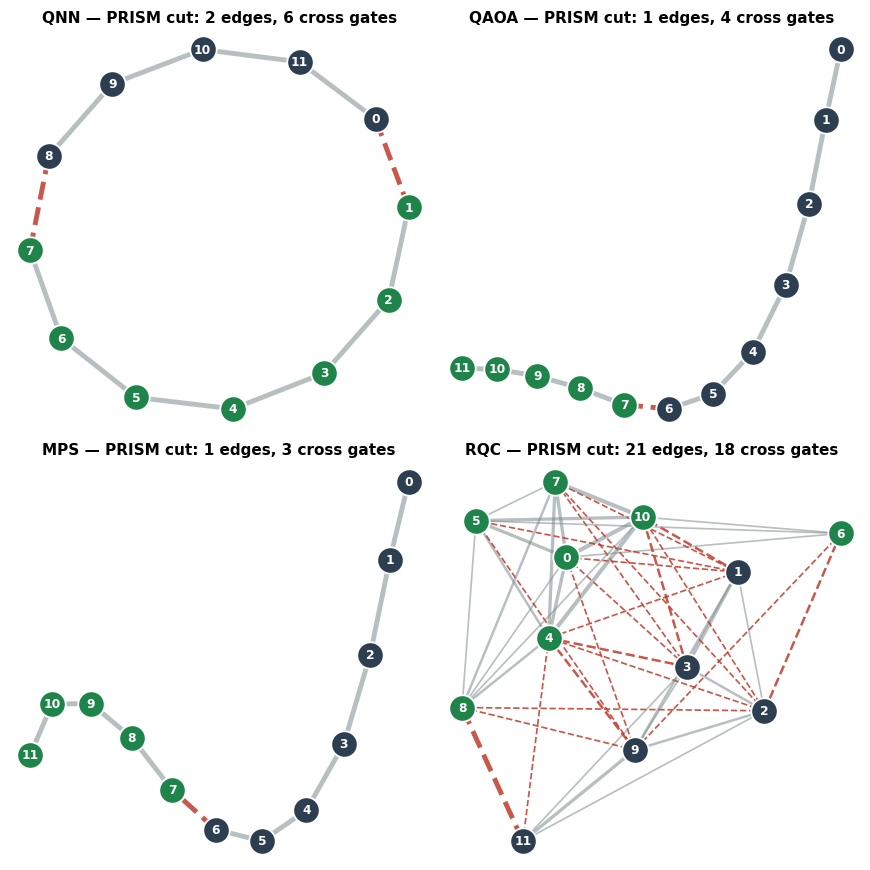

In [ ]:
# ── Figure 2: interaction graphs with the PRISM bipartition overlaid ─────────
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, fam in zip(axes.flat, FAM_LIST):
    layout, qc, G = SHOW[fam]
    A, B = mosaic_lct(G, layout, N_SHOW, qc_full=qc, seed=SEED_SHOW)
    gc = rrc.classify_gates(layout, A, B)
    qpd = rrc.compute_qpd_overhead(gc['cross'], sym_reduction=True)
    pos = nx.spring_layout(G, seed=3, weight='weight')
    wmax = max((d.get('weight', 1.0) for *_, d in G.edges(data=True)), default=1.0)
    for u, v, d in G.edges(data=True):
        cut = (u in A) != (v in A)
        ax.plot(*zip(pos[u], pos[v]), color='#C0392B' if cut else '#7F8C8D',
                lw=0.6 + 2.6 * d.get('weight', 1.0) / wmax,
                ls='--' if cut else '-', alpha=0.85 if cut else 0.55, zorder=1)
    for q in G.nodes():
        ax.scatter(*pos[q], s=300, zorder=2,
                   c='#1E8449' if q in A else '#2C3E50', edgecolors='white', linewidths=1.2)
        ax.annotate(str(q), pos[q], ha='center', va='center', color='white',
                    fontsize=8, fontweight='bold', zorder=3)
    n_cut = sum(1 for u, v in G.edges() if (u in A) != (v in A))
    ax.set_title(f"{fam} — PRISM cut: {n_cut} edges, {len(gc['cross'])} cross gates"
                 )
    ax.axis('off')

fig.tight_layout(); savefig(fig, 'f02_interaction_graphs.png'); plt.show()

## 2. Experiment 1 — all partition methods × {QNN, QAOA, MPS, RQC}

**Design.** Families × *n* ∈ {8, 10, 12} × 5 seeds = 60 circuit instances; each is partitioned by all eleven methods. Per (instance, method) we record structural metrics and, from exact statevectors, the product-reconstruction distances against the ideal full distribution. The unified score and rank are computed within each instance via the codebase's `_compute_unified_scores` (weights: TVD 0.25, fidelity 0.25, KL 0.15, JS 0.15, Hellinger 0.10, cross-entropy 0.10).

A method can legitimately fail on an instance (e.g. METIS unavailable, degenerate graphs); failures are counted and reported rather than silently dropped.

In [ ]:
# ── Experiment 1 runner ───────────────────────────────────────────────────────
QUBITS = [6, 8, 10, 12, 14, 16]
SEEDS  = [19, 23, 29, 31, 37]

rows, fail_log = [], defaultdict(int)
t0_all = time.time()
for family in FAM_LIST:
    for n in QUBITS:
        for seed in SEEDS:
            random.seed(seed); np.random.seed(seed)
            layout = make_layout(family, n, seed)
            qc_full, _ = compile_quantum_circuit(layout, num_qubits=n, use_numeric_params=True)
            G = rrc.build_interaction_graph(layout, n)
            sv = rrc._get_statevector(qc_full)
            p_ideal = rrc._prob_from_statevector(sv) if sv is not None else None

            methods, fails = run_all_partition_methods(G, layout, n, qc_full, seed)
            for k in fails:
                fail_log[k] += 1

            inst, recon_metrics = [], {}
            for m, (A, B, dt) in methods.items():
                cs  = rrc.compute_cut_stats(G, A, B)
                gc  = rrc.classify_gates(layout, A, B)
                qpd = rrc.compute_qpd_overhead(gc['cross'], sym_reduction=True)
                ent = rrc._entanglement_entropy(sv, sorted(A), n) if sv is not None else None
                dm = {}
                if p_ideal is not None:
                    p_rec = reconstruct_product(A, B, layout, n)
                    if p_rec is not None:
                        dm = rrc._compute_distribution_metrics(p_ideal, p_rec)
                        recon_metrics[m] = {**dm, 'error': None}
                inst.append(dict(
                    family=family, n_qubits=n, seed=seed, method=m,
                    n_A=len(A), n_B=len(B),
                    balance=round(min(len(A), len(B)) / max(len(A), len(B), 1), 4),
                    n_cut_edges=cs['n_cut_edges'], cut_weight=cs['cut_weight'],
                    cut_fraction=cs['cut_fraction'], n_cross_gates=len(gc['cross']),
                    log10_gamma_sym=math.log10(max(qpd['total_gamma_sym'], 1e-12)),
                    entanglement_entropy=ent, runtime_s=dt, **dm))
            scored = rrc._compute_unified_scores(recon_metrics)
            for r in inst:
                s = scored.get(r['method'], {})
                r['unified_score'], r['rank'] = s.get('unified_score'), s.get('rank')
            rows.extend(inst)
    print(f'  {family:5s} done  ({time.time() - t0_all:5.0f} s elapsed)')

df1 = pd.DataFrame(rows)
df1.to_csv(OUT / 'exp1_partition_benchmark.csv', index=False)
METHODS_SEEN = [m for m in METHOD_ORDER if m in set(df1.method)]
print(f'\n{df1.shape[0]} rows × {df1.shape[1]} cols  →  {OUT / "exp1_partition_benchmark.csv"}')
print('method failures:', dict(fail_log) if fail_log else 'none')
df1

  QNN   done  (  128 s elapsed)
  QAOA  done  (  247 s elapsed)
  MPS   done  (  377 s elapsed)
  RQC   done  (  535 s elapsed)

1320 rows × 22 cols  →  prism_notebook_results/exp1_partition_benchmark.csv
method failures: none


,family,n_qubits,seed,method,n_A,n_B,balance,n_cut_edges,cut_weight,cut_fraction,...,entanglement_entropy,runtime_s,tvd,fidelity,kl_divergence,hellinger,js_divergence,cross_entropy,unified_score,rank
0,QNN,6,19,Naive,3,3,1.0000,2,6,0.3333,...,1.979418,0.000007,0.466853,0.824712,0.798600,0.418674,0.159892,4.484678,1.000000,1
1,QNN,6,19,Spectral,3,3,1.0000,2,6,0.3333,...,2.102105,0.003905,0.593502,0.724479,1.330834,0.524901,0.249526,5.016912,0.000000,10
2,QNN,6,19,Louvain,4,2,0.5000,2,6,0.3333,...,1.798656,0.000841,0.550988,0.759201,1.126789,0.490713,0.218204,4.812866,0.350968,7
3,QNN,6,19,Girvan-Newman,3,3,1.0000,2,6,0.3333,...,2.143424,0.002001,0.527888,0.754467,1.137696,0.495513,0.220426,4.823773,0.371399,4
4,QNN,6,19,METIS,3,3,1.0000,2,6,0.3333,...,2.102105,0.001515,0.593502,0.724479,1.330834,0.524901,0.249526,5.016912,0.000000,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,RQC,16,37,mosaic-KL,8,8,1.0000,32,40,0.3670,...,2.649715,0.001201,0.708879,0.495557,7.481375,0.710242,0.396068,14.940257,0.335125,9
1316,RQC,16,37,mosaic-OE,8,8,1.0000,29,40,0.3670,...,2.777370,0.059147,0.690168,0.522067,7.765427,0.691327,0.385468,15.224310,0.410804,5
1317,RQC,16,37,mosaic-MI,9,7,0.7778,28,38,0.3486,...,1.313488,3.863189,0.676790,0.566008,7.399246,0.658781,0.352457,14.858128,0.580014,3
1318,RQC,16,37,mosaic-BF,8,8,1.0000,29,40,0.3670,...,2.777370,5.158181,0.690168,0.522067,7.765427,0.691327,0.385468,15.224310,0.410804,6


In [ ]:
# ── shared plot helpers for Experiment 1 ─────────────────────────────────────
def box_by_method(ax, sub, value, title, ylabel, log=False):
    methods = [m for m in METHODS_SEEN if sub.loc[sub.method == m, value].notna().any()]
    data = [sub.loc[sub.method == m, value].dropna().values for m in methods]
    bp = ax.boxplot(data, patch_artist=True, widths=0.62, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white',
                                   markeredgecolor='black', markersize=4))
    for m, patch in zip(methods, bp['boxes']):
        patch.set_facecolor(METHOD_COLOURS.get(m, '#BDC3C7')); patch.set_alpha(0.85)
        if m == PRISM:
            patch.set_edgecolor('#0B3D1E'); patch.set_linewidth(2.2)
    for med in bp['medians']:
        med.set_color('black'); med.set_linewidth(1.4)
    ax.set_xticks(range(1, len(methods) + 1))
    ax.set_xticklabels(methods, rotation=38, ha='right', fontsize=7.5)
    ax.set_title(title); ax.set_ylabel(ylabel)
    if log:
        ax.set_yscale('log')

def heat(ax, M, xlab, ylab, title, cmap='viridis_r', fmt='{:.3f}', vmin=None, vmax=None):
    im = ax.imshow(M, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(xlab))); ax.set_xticklabels(xlab, rotation=38, ha='right', fontsize=7.5)
    ax.set_yticks(range(len(ylab))); ax.set_yticklabels(ylab, fontsize=8.5)
    lo, hi = np.nanmin(M), np.nanmax(M)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if np.isfinite(M[i, j]):
                frac = 0.5 if hi - lo < 1e-12 else (M[i, j] - lo) / (hi - lo)
                ax.text(j, i, fmt.format(M[i, j]), ha='center', va='center', fontsize=7,
                        color='white' if frac > 0.55 else 'black')
    ax.set_title(title); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

def fam_method_matrix(value, aggfn='mean'):
    pv = df1.pivot_table(index='family', columns='method', values=value, aggfunc=aggfn)
    return pv.reindex(index=FAM_LIST, columns=METHODS_SEEN)
print('helpers ready')

helpers ready


## 3. Experiment 2 — PRISM reconstruction, noise-free and under noise

**Protocol.** *n* = 10, 3 seeds per family. PRISM partitions each instance once (the partition is noise-independent); the full circuit and both fragments are transpiled to the basis {rz, sx, x, cx} and simulated **exactly**: statevector at zero noise, density matrix otherwise — so every curve below is shot-noise-free.

**Noise model.** Depolarising channels on the transpiled basis: probability p₂ after every `cx`, p₂/10 after every `sx`/`x`; `rz` is a virtual frame change and is left noise-free (standard superconducting convention). p₂ sweeps {0, 0.002, 0.005, 0.01, 0.02, 0.04} — current hardware sits around 0.005–0.01. Readout error is deliberately omitted: the same per-qubit confusion matrix would act on all *n* measured bits whether the circuit is cut or not, so it cancels in the cut-vs-uncut comparison while slowing the sweep.

**Three distances per noise level** (all against the ideal noiseless full distribution p\*): (i) noisy **full**-circuit execution vs p\* — what uncut hardware delivers; (ii) noisy **PRISM reconstruction** p̂ = p_A ⊗ p_B vs p\*; (iii) recon vs noisy-full, for reference. At p₂ = 0 the full circuit is exact by construction, so the recon curve starts at the **product-approximation floor** — the honest question is where (and whether) the two curves cross as fragments accumulate less noise than the full circuit.

In [ ]:
# ── noise helpers ─────────────────────────────────────────────────────────────
BASIS = ['rz', 'sx', 'x', 'cx']

def make_noise_model(p2):
    if p2 <= 0:
        return None
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p2 / 10, 1), ['sx', 'x'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ['cx'])
    return nm

_TC = {}
def transpiled(qc, key, seed=7):
    if key not in _TC:
        _TC[key] = transpile(qc, basis_gates=BASIS, optimization_level=1, seed_transpiler=seed)
    return _TC[key]

def probs_exact_or_noisy(tqc, p2, seed=7):
    """Exact probabilities: |ψ|² at p2 = 0, density-matrix diagonal otherwise."""
    if p2 <= 0:
        return rrc._prob_from_statevector(rrc._get_statevector(tqc))
    sim = AerSimulator(method='density_matrix', noise_model=make_noise_model(p2))
    run_qc = tqc.copy(); run_qc.save_probabilities()
    return np.asarray(sim.run(run_qc, seed_simulator=seed).result().data(0)['probabilities'])

def prism_fragments(layout, A, B, n):
    gc = rrc.classify_gates(layout, A, B)
    out = {}
    for side, nodes in (('A', A), ('B', B)):
        sub, sorted_nodes, _ = rrc.build_subcircuit_layout(layout, nodes, side, gc)
        out[side] = (rrc._materialize_layout_circuit(sub, len(nodes)), sorted_nodes)
    return out
print('noise helpers ready | basis:', BASIS)

noise helpers ready | basis: ['rz', 'sx', 'x', 'cx']


In [ ]:
# ── Experiment 2 runner ───────────────────────────────────────────────────────
N_NOISE     = 10
P2_LEVELS   = [0.0, 0.002, 0.005, 0.01, 0.02, 0.04]
SEEDS_NOISE = [19, 23, 29]

rows2, frag_rows, SNAP = [], [], {}
t0_all = time.time()
for family in FAM_LIST:
    for seed in SEEDS_NOISE:
        random.seed(seed); np.random.seed(seed)
        layout = make_layout(family, N_NOISE, seed)
        qc_full, _ = compile_quantum_circuit(layout, num_qubits=N_NOISE, use_numeric_params=True)
        G = rrc.build_interaction_graph(layout, N_NOISE)
        A, B = mosaic_lct(G, layout, N_NOISE, qc_full=qc_full, seed=seed)
        p_ideal = rrc._prob_from_statevector(rrc._get_statevector(qc_full))

        frags = prism_fragments(layout, A, B, N_NOISE)
        t_full = transpiled(rrc._materialize_layout_circuit(layout, N_NOISE), (family, seed, 'full'))
        t_A = transpiled(frags['A'][0], (family, seed, 'A'))
        t_B = transpiled(frags['B'][0], (family, seed, 'B'))
        for tag, tq, nq in (('full', t_full, N_NOISE), ('A', t_A, len(A)), ('B', t_B, len(B))):
            ops = tq.count_ops()
            frag_rows.append(dict(family=family, seed=seed, part=tag, n_qubits=nq,
                                  depth=tq.depth(), cx=int(ops.get('cx', 0)),
                                  oneq=int(sum(v for k, v in ops.items() if k in ('sx', 'x', 'rz')))))

        idxA = rrc._build_recon_index(frags['A'][1], N_NOISE)
        idxB = rrc._build_recon_index(frags['B'][1], N_NOISE)
        for p2 in P2_LEVELS:
            p_full = probs_exact_or_noisy(t_full, p2)
            pA, pB = probs_exact_or_noisy(t_A, p2), probs_exact_or_noisy(t_B, p2)
            p_rec = pA[idxA] * pB[idxB]; p_rec = p_rec / p_rec.sum()
            m_full = rrc._compute_distribution_metrics(p_ideal, p_full)
            m_rec  = rrc._compute_distribution_metrics(p_ideal, p_rec)
            rows2.append(dict(family=family, seed=seed, p2=p2, n_A=len(A), n_B=len(B),
                              **{f'{k}_full': v for k, v in m_full.items()},
                              **{f'{k}_recon': v for k, v in m_rec.items()},
                              tvd_recon_vs_noisyfull=rrc._compute_distribution_metrics(p_full, p_rec)['tvd']))
            if seed == SEEDS_NOISE[0] and p2 in (0.0, 0.02):
                SNAP[(family, p2)] = (p_ideal.copy(), p_full.copy(), p_rec.copy())
    print(f'  {family:5s} done  ({time.time() - t0_all:5.0f} s elapsed)')

df2 = pd.DataFrame(rows2); frag_df = pd.DataFrame(frag_rows)
df2.to_csv(OUT / 'exp2_noise_reconstruction.csv', index=False)
frag_df.to_csv(OUT / 'exp2_fragment_stats.csv', index=False)

# internal consistency: Exp 2 recon at p2 = 0 must match Exp 1's PRISM rows
chk = (df2[df2.p2 == 0].set_index(['family', 'seed'])['tvd_recon']
       - df1[(df1.method == PRISM) & (df1.n_qubits == N_NOISE) & df1.seed.isin(SEEDS_NOISE)]
            .set_index(['family', 'seed'])['tvd']).abs().max()
print(f'\n{len(df2)} rows → {OUT / "exp2_noise_reconstruction.csv"}')
print(f'consistency vs Experiment 1 (PRISM, n=10, p2=0): max |ΔTVD| = {chk:.2e}')
df2.head(4)

  QNN   done  (    5 s elapsed)
  QAOA  done  (    9 s elapsed)
  MPS   done  (   15 s elapsed)
  RQC   done  (   29 s elapsed)

72 rows → prism_notebook_results/exp2_noise_reconstruction.csv
consistency vs Experiment 1 (PRISM, n=10, p2=0): max |ΔTVD| = 4.44e-16


,family,seed,p2,n_A,n_B,tvd_full,fidelity_full,kl_divergence_full,hellinger_full,js_divergence_full,cross_entropy_full,tvd_recon,fidelity_recon,kl_divergence_recon,hellinger_recon,js_divergence_recon,cross_entropy_recon,tvd_recon_vs_noisyfull
0,QNN,19,0.000,4,6,1.878334e-15,1.000000,-2.490560e-16,1.845374e-15,0.000000,6.120078,0.419975,0.845335,0.673807,0.393275,0.140162,6.793885,0.419975
1,QNN,19,0.002,4,6,1.750382e-02,0.999228,2.681474e-03,2.778899e-02,0.000746,6.122759,0.415767,0.851409,0.605793,0.385475,0.135810,6.725871,0.405799
2,QNN,19,0.005,4,6,4.232630e-02,0.996694,1.123293e-02,5.749901e-02,0.003173,6.131311,0.410408,0.857204,0.559608,0.377884,0.131205,6.679686,0.385814
3,QNN,19,0.010,4,6,8.018800e-02,0.990745,3.098662e-02,9.620278e-02,0.008824,6.151065,0.404006,0.863221,0.519911,0.369837,0.126191,6.639989,0.355748


[saved] prism_notebook_results/f12_tvd_vs_noise.png


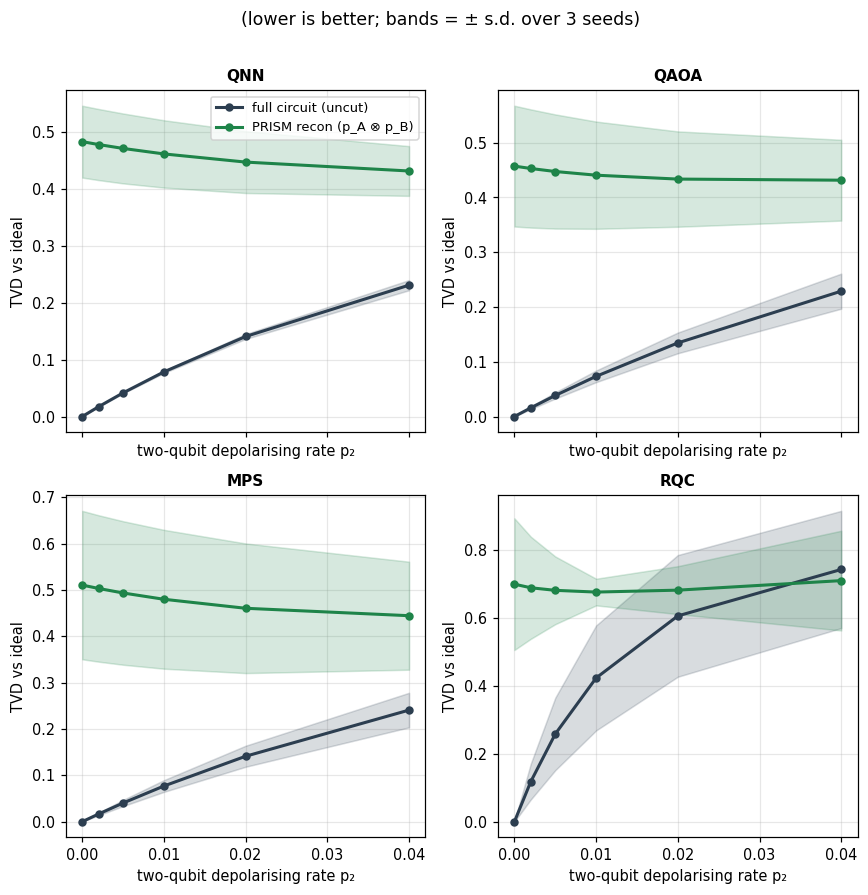

In [ ]:
# ── Figures 12–13: TVD and fidelity vs noise strength, per family ─────────────
def noise_curves(metric, ylabel, better, fname, title):
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True)
    for ax, fam in zip(axes.flat, FAM_LIST):
        sub = df2[df2.family == fam]
        for src, colr, lab in [('full', '#2C3E50', 'full circuit (uncut)'),
                               ('recon', '#1E8449', 'PRISM recon (p_A ⊗ p_B)')]:
            g = sub.groupby('p2')[f'{metric}_{src}'].agg(['mean', 'std'])
            ax.plot(g.index, g['mean'], 'o-', color=colr, lw=2, ms=4.5, label=lab)
            ax.fill_between(g.index, g['mean'] - g['std'], g['mean'] + g['std'],
                            color=colr, alpha=0.18)
        ax.set_title(fam); ax.set_ylabel(ylabel)
        ax.set_xlabel('two-qubit depolarising rate p₂')
    axes.flat[0].legend(fontsize=8.5)
    fig.suptitle(title + f'  ({better}; bands = ± s.d. over 3 seeds)', y=1.01)
    fig.tight_layout(); savefig(fig, fname); plt.show()

noise_curves('tvd', 'TVD vs ideal', 'lower is better', 'f12_tvd_vs_noise.png',
             '')

[saved] prism_notebook_results/f13_fid_vs_noise.png


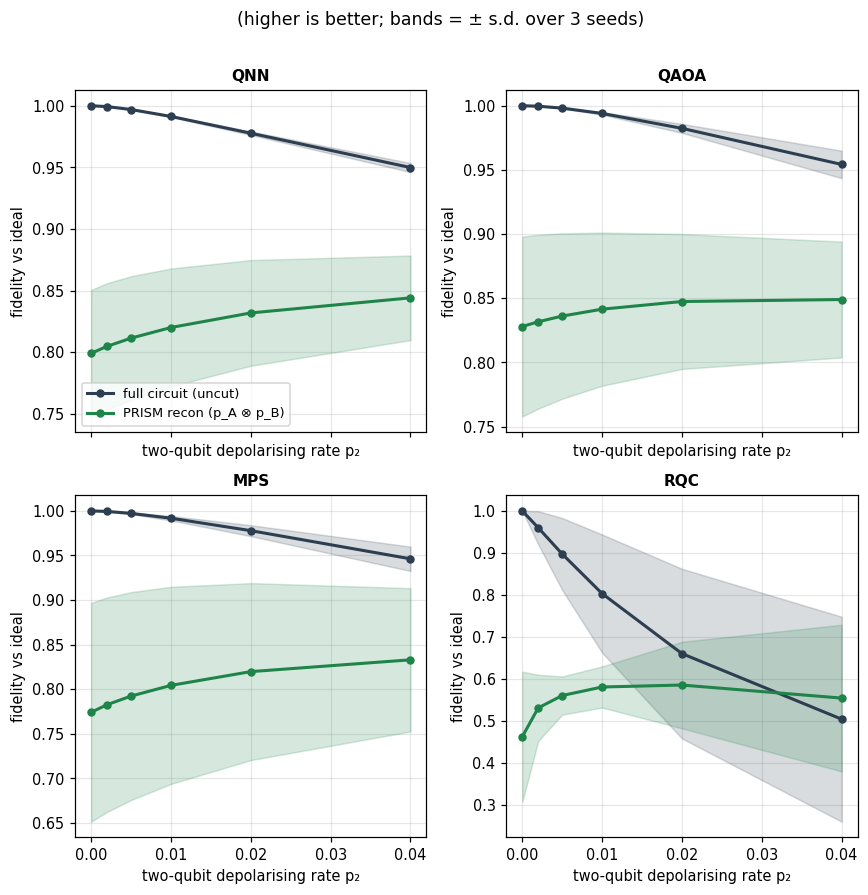

In [ ]:
noise_curves('fidelity', 'fidelity vs ideal', 'higher is better', 'f13_fid_vs_noise.png',
             '')

[saved] prism_notebook_results/f16_topk_overlay.png


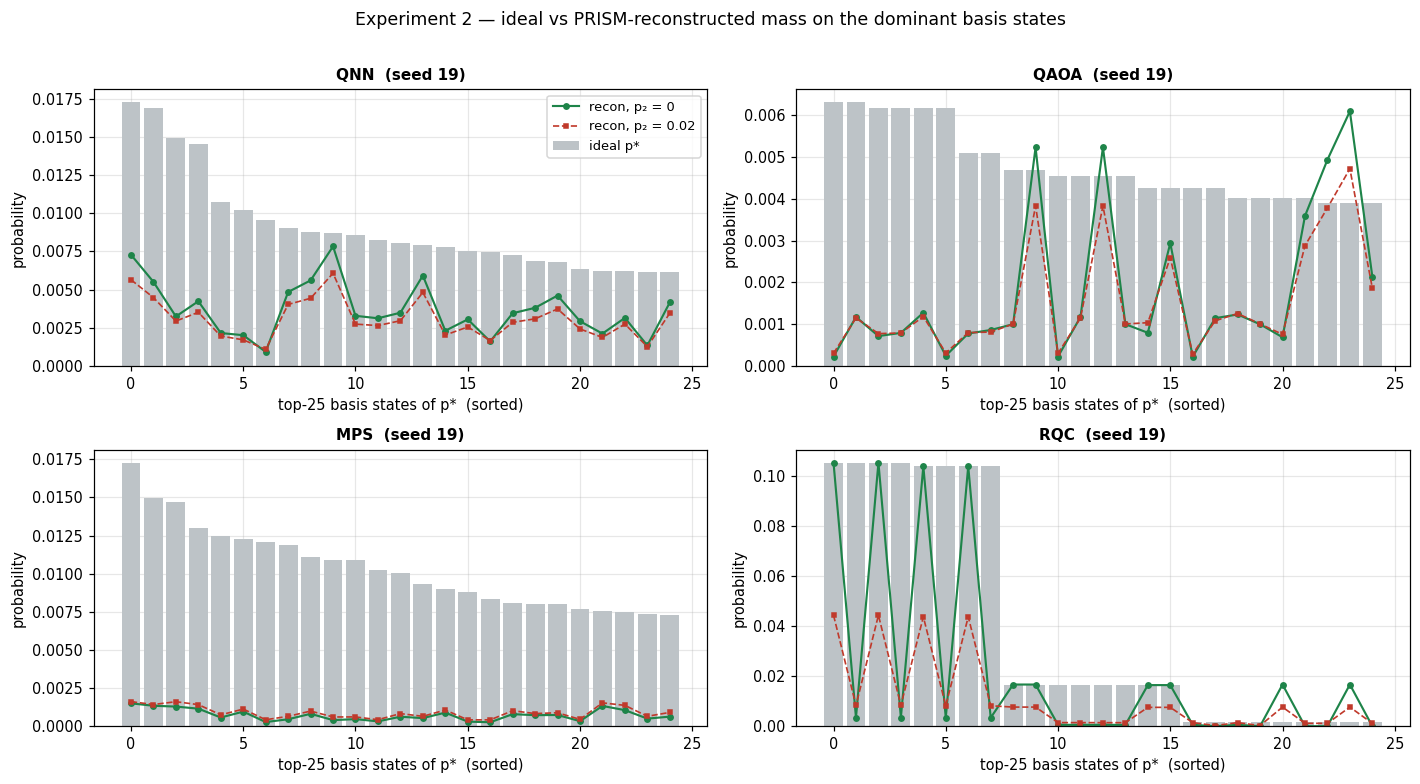

In [ ]:
# ── Figure 16: where the probability mass goes — top-25 bitstrings ────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
K = 25
for ax, fam in zip(axes.flat, FAM_LIST):
    p_ideal, _, p_rec0 = SNAP[(fam, 0.0)]
    _, _, p_rec_noisy = SNAP[(fam, 0.02)]
    top = np.argsort(p_ideal)[::-1][:K]
    x = np.arange(K)
    ax.bar(x, p_ideal[top], color='#BDC3C7', label='ideal p*', width=0.84)
    ax.plot(x, p_rec0[top], 'o-', color='#1E8449', ms=3.5, lw=1.4, label='recon, p₂ = 0')
    ax.plot(x, p_rec_noisy[top], 's--', color='#C0392B', ms=3, lw=1.1, label='recon, p₂ = 0.02')
    ax.set_title(f'{fam}  (seed {SEEDS_NOISE[0]})'); ax.set_ylabel('probability')
    ax.set_xlabel(f'top-{K} basis states of p*  (sorted)')
axes.flat[0].legend(fontsize=8.5)
fig.suptitle('Experiment 2 — ideal vs PRISM-reconstructed mass on the dominant basis states', y=1.01)
fig.tight_layout(); savefig(fig, 'f16_topk_overlay.png'); plt.show()

[saved] prism_notebook_results/f17_scatter.png


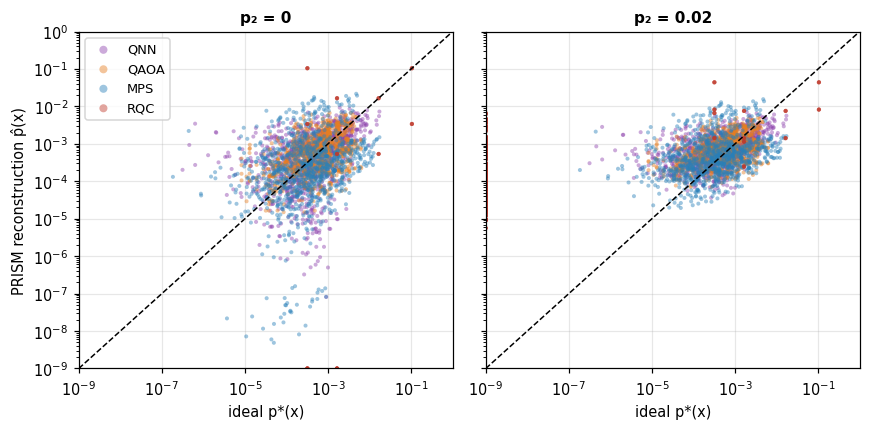

In [ ]:
# ── Figure 17: per-bitstring agreement, noise-free vs noisy ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
lims = (1e-9, 1.0)
for ax, p2 in zip(axes, (0.0, 0.02)):
    for fam in FAM_LIST:
        p_ideal, _, p_rec = SNAP[(fam, p2)]
        ax.scatter(np.clip(p_ideal, *lims), np.clip(p_rec, *lims), s=7, alpha=0.45,
                   c=FAMILY_COLOURS[fam], label=fam, edgecolors='none')
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(*lims); ax.set_ylim(*lims)
    ax.set_xlabel('ideal p*(x)'); ax.set_title(f'p₂ = {p2:g}')
axes[0].set_ylabel('PRISM reconstruction p̂(x)')
axes[0].legend(fontsize=8.5, markerscale=2)
#fig.suptitle('Experiment 2 — per-basis-state scatter (all 1024 states, one seed per family); '
#             'the y = x diagonal is exact agreement', y=1.02)
fig.tight_layout(); savefig(fig, 'f17_scatter.png'); plt.show()